# Experiment 4: Data Preprocessing and Exploration

**Description:** Descriptive analysis, handling of null values, data normalization and data
discretization on the Bitcoin case-study dataset.

**Case study:** *Predicting Trends and Uncovering Patterns in Bitcoin Price Movement Using Data Mining Techniques*

**Parts of this experiment**
- **Part A — cleaning** (`data_cleaning_v2.py`): gap filling, duplicate removal, recomputation of the
  derived columns. Produces `btc_cleaned_v2.csv`.
- **Part B — this notebook**: descriptive analysis, null-value handling, normalization, discretization.
- **Part C — exploration** (`experiment_5.ipynb`): feature transformation, outlier analysis and
  visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

import os, warnings
warnings.filterwarnings('ignore')
OUT = "exp4_outputs"; os.makedirs(OUT, exist_ok=True)

RAW   = "btc_flat_final_2.csv"     # before cleaning
CLEAN = "btc_cleaned_v2.csv"       # after Part A

## 1. Descriptive Analysis

Descriptive statistics summarise the central tendency, dispersion and shape of each attribute. They are
the first thing to look at, because every later decision — which nulls to fill, what to normalise, where
to place discretization cut-points — follows from them.

In [2]:
raw = pd.read_csv(RAW, parse_dates=['date'])
df  = pd.read_csv(CLEAN, parse_dates=['date'])

print(f"Raw     : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Cleaned : {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"({df['date'].min().date()} to {df['date'].max().date()})")
df.head()

Raw     : 5,684 rows x 20 columns
Cleaned : 5,534 rows x 21 columns (2011-02-01 to 2026-03-27)


,date,ticker,halving_era,days_since_halving,open,high,low,close,daily_change,daily_pct_change,daily_range,ma_7,ma_30,ma_200,volatility_30d,ema_12,ema_26,macd,macd_signal,rsi_14,is_interpolated
0,2011-02-01,BTC,Genesis Era (50 BTC/block),759,0.520,0.85,0.5200,0.700,0.180,34.615385,0.3300,0.489014,0.384810,0.178366,9.753646,0.477095,0.415837,0.061258,0.041056,85.716762,False
1,2011-02-02,BTC,Genesis Era (50 BTC/block),760,0.700,0.76,0.6900,0.716,0.016,2.285714,0.0700,0.531729,0.398843,0.181698,9.711259,0.513850,0.438071,0.075778,0.048000,86.263305,False
2,2011-02-03,BTC,Genesis Era (50 BTC/block),761,0.716,0.75,0.6501,0.690,-0.026,-3.631285,0.0999,0.570129,0.411880,0.184719,9.789639,0.540950,0.456733,0.084217,0.055244,80.849378,False
3,2011-02-04,BTC,Genesis Era (50 BTC/block),762,0.690,0.88,0.6700,0.811,0.121,17.536232,0.2100,0.622271,0.428947,0.188370,10.108482,0.582496,0.482975,0.099521,0.064099,85.431750,False
4,2011-02-05,BTC,Genesis Era (50 BTC/block),763,0.811,0.92,0.8110,0.920,0.109,13.440197,0.1090,0.690986,0.449680,0.192597,10.225404,0.634420,0.515347,0.119073,0.075094,88.176380,False


In [3]:
NUM = ['open', 'high', 'low', 'close', 'daily_change', 'daily_pct_change',
       'daily_range', 'ma_7', 'ma_30', 'ma_200', 'volatility_30d', 'rsi_14']

desc = df[NUM].describe().T
desc['median']   = df[NUM].median()
desc['mode']     = df[NUM].mode().iloc[0]
desc['variance'] = df[NUM].var()
desc['skewness'] = df[NUM].skew()
desc['kurtosis'] = df[NUM].kurtosis()
desc['range']    = desc['max'] - desc['min']
desc['IQR']      = df[NUM].quantile(0.75) - df[NUM].quantile(0.25)
desc = desc[['count', 'mean', 'median', 'mode', 'std', 'variance', 'min', '25%', '50%', '75%',
             'max', 'range', 'IQR', 'skewness', 'kurtosis']]
print("DESCRIPTIVE STATISTICS")
desc.round(3)

DESCRIPTIVE STATISTICS


,count,mean,median,mode,std,variance,min,25%,50%,75%,max,range,IQR,skewness,kurtosis
open,5534.0,21259.080,6599.850,5.100,30507.950,9.307350e+08,0.520,350.918,6599.850,30799.950,125172.700,125172.180,30449.032,1.601,1.592
high,5534.0,21688.312,6764.290,5.000,31009.607,9.615957e+08,0.748,363.912,6764.290,31824.050,126300.600,126299.852,31460.138,1.585,1.526
low,5534.0,20747.213,6469.580,5.100,29833.362,8.900295e+08,0.520,340.038,6469.580,30117.775,122812.500,122811.980,29777.738,1.611,1.640
close,5534.0,21244.107,6607.300,5.100,30441.626,9.266926e+08,0.680,351.238,6607.300,30808.050,125173.000,125172.320,30456.812,1.595,1.572
daily_change,5534.0,-14.973,0.050,0.000,985.656,9.715169e+05,-8570.450,-54.942,0.050,63.893,8138.700,16709.150,118.835,-0.144,12.154
daily_pct_change,5534.0,0.340,0.093,0.000,6.726,4.524500e+01,-57.206,-1.330,0.093,1.778,336.839,394.045,3.107,23.981,1159.817
daily_range,5534.0,941.099,231.480,0.240,1524.814,2.325059e+06,0.000,11.083,231.480,1278.950,18347.300,18347.300,1267.867,2.615,9.910
ma_7,5534.0,21206.763,6578.868,4.854,30409.010,9.247079e+08,0.489,349.229,6578.868,30550.300,122800.514,122800.025,30201.071,1.597,1.576
ma_30,5534.0,21060.275,6657.836,4.847,30282.273,9.170160e+08,0.385,358.313,6657.836,30367.556,117479.000,117478.615,30009.242,1.605,1.603
ma_200,5534.0,19764.184,6460.664,0.178,28771.701,8.278108e+08,0.178,320.816,6460.664,29449.579,110448.024,110447.846,29128.763,1.667,1.869


In [4]:
print("Shape of the distribution — what the skew and kurtosis mean here")
for col in ['close', 'daily_pct_change', 'daily_range', 'rsi_14']:
    s, k = df[col].skew(), df[col].kurtosis()
    shape = ("strongly right-skewed" if s > 1 else "right-skewed" if s > 0.5
             else "roughly symmetric" if abs(s) <= 0.5 else "left-skewed")
    tails = "heavy-tailed (leptokurtic)" if k > 3 else "light-tailed" if k < 0 else "near-normal tails"
    print(f"  {col:18s} skew={s:8.3f}  kurtosis={k:9.3f}   -> {shape}, {tails}")

Shape of the distribution — what the skew and kurtosis mean here
  close              skew=   1.595  kurtosis=    1.572   -> strongly right-skewed, near-normal tails
  daily_pct_change   skew=  23.981  kurtosis= 1159.817   -> strongly right-skewed, heavy-tailed (leptokurtic)
  daily_range        skew=   2.615  kurtosis=    9.910   -> strongly right-skewed, heavy-tailed (leptokurtic)
  rsi_14             skew=   0.270  kurtosis=   -0.224   -> roughly symmetric, light-tailed


In [5]:
# Central tendency and dispersion by halving era - the group comparison the case study asks for
era_stats = df.groupby('halving_era').agg(
    days=('close', 'size'),
    mean_close=('close', 'mean'),
    median_close=('close', 'median'),
    std_pct_change=('daily_pct_change', 'std'),
    mean_abs_move=('daily_pct_change', lambda s: s.abs().mean()),
    mean_rsi=('rsi_14', 'mean'))
order = df.groupby('halving_era')['date'].min().sort_values().index
era_stats = era_stats.loc[order].round(3)
print("DESCRIPTIVE STATISTICS BY HALVING ERA")
era_stats

DESCRIPTIVE STATISTICS BY HALVING ERA


,days,mean_close,median_close,std_pct_change,mean_abs_move,mean_rsi
halving_era,,,,,,
Genesis Era (50 BTC/block),666,6.953,5.555,7.395,4.245,54.743
Post-Halving 1 (25 BTC/block),1319,343.291,314.120,11.367,3.433,54.667
Post-Halving 2 (12.5 BTC/block),1402,5765.025,6344.345,4.142,2.724,53.971
Post-Halving 3 (6.25 BTC/block),1440,32831.496,29955.750,3.219,2.210,53.441
Post-Halving 4 (3.125 BTC/block),707,87337.398,89340.570,2.464,1.822,52.030


## 2. Handling Null Values

The raw file contains 279 nulls. They are not all the same kind of missing value, so they do not all get
the same treatment — this is the whole point of the section.

In [6]:
null_profile = pd.DataFrame({
    'null_count': raw.isnull().sum(),
    'null_pct'  : (raw.isnull().mean() * 100).round(3)})
null_profile = null_profile[null_profile.null_count > 0].sort_values('null_count', ascending=False)
print("NULL VALUE PROFILE OF THE RAW DATA")
print(null_profile.to_string())
print(f"\nTotal nulls: {int(raw.isnull().sum().sum())}")
print(f"Rows with at least one null: {int(raw.isnull().any(axis=1).sum())} "
      f"({raw.isnull().any(axis=1).mean()*100:.2f}%)")

NULL VALUE PROFILE OF THE RAW DATA
                null_count  null_pct
ma_200                 199     3.501
ma_30                   29     0.510
volatility_30d          29     0.510
rsi_14                  14     0.246
ma_7                     6     0.106
high                     1     0.018
ticker                   1     0.018

Total nulls: 279
Rows with at least one null: 199 (3.50%)


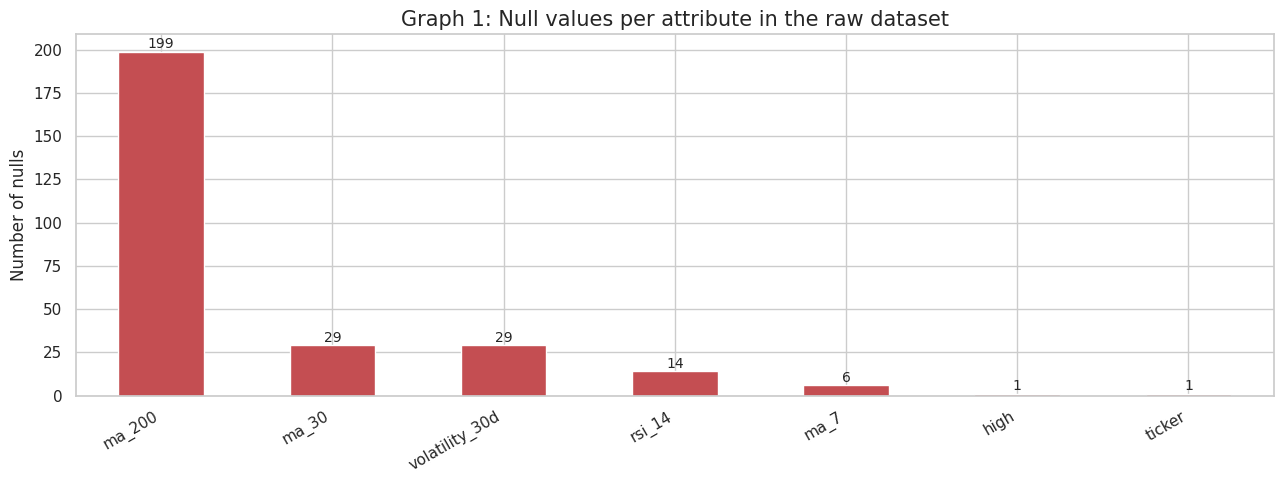

In [7]:
plt.figure(figsize=(13, 5))
ax = null_profile['null_count'].plot(kind='bar', color='#c44e52')
for i, v in enumerate(null_profile['null_count']):
    ax.text(i, v + 2, str(int(v)), ha='center', fontsize=10)
plt.title('Graph 1: Null values per attribute in the raw dataset', fontsize=15)
plt.ylabel('Number of nulls'); plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig(f"{OUT}/exp4_g1_nulls.png", dpi=150); plt.show()

### 2.1 Why each null occurs, and the treatment chosen

| Attribute | Nulls | Cause | Treatment |
|---|---|---|---|
| `ma_200`, `ma_30`, `ma_7`, `volatility_30d`, `rsi_14` | 199, 29, 6, 29, 14 | **structural** — a rolling window cannot produce a value until it is full (burn-in) | drop the burn-in rows; imputing them would invent indicator history |
| `high` | 1 | **missing at random** — one bad record | repaired from the OHLC relation (`high = max(open, high, low, close)`) |
| `ticker` | 1 | **missing at random** in a constant column | forward fill |
| 50 absent calendar days | — | **missing rows**, not missing cells | insert the dates and linearly interpolate the prices, flagged with `is_interpolated` |

The four generic strategies were compared before choosing.

In [8]:
# Where exactly are the rsi_14 nulls?
target = 'rsi_14'
null_pos = np.where(raw[target].isnull())[0]
print(f"{target}: {len(null_pos)} nulls at row positions {null_pos.tolist()}")
print("-> they are the LEADING rows, i.e. structural burn-in, not values lost at random.\n")

strategies = {
    'Listwise deletion'   : raw[target].dropna(),
    'Mean imputation'     : raw[target].fillna(raw[target].mean()),
    'Median imputation'   : raw[target].fillna(raw[target].median()),
    'Forward fill'        : raw[target].ffill(),
    'Backward fill'       : raw[target].bfill(),
    'Linear interpolation': raw[target].interpolate(method='linear'),
}
comparison = pd.DataFrame({
    name: {'values kept': int(s.notna().sum()), 'nulls left': int(s.isna().sum()),
           'mean': s.mean(), 'std': s.std()}
    for name, s in strategies.items()}).T.round(4)
print("EFFECT OF EACH STRATEGY ON A STRUCTURAL (LEADING) NULL BLOCK")
print(comparison.to_string())
print("\nForward fill and interpolation cannot repair a LEADING gap - there is no earlier value to")
print("carry forward. Only deletion, back-fill or mean/median imputation change anything, and the last")
print("two would invent 14 days of indicator history. Dropping the burn-in is therefore the right call.")

rsi_14: 14 nulls at row positions [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
-> they are the LEADING rows, i.e. structural burn-in, not values lost at random.

EFFECT OF EACH STRATEGY ON A STRUCTURAL (LEADING) NULL BLOCK
                      values kept  nulls left     mean      std
Listwise deletion          5670.0         0.0  54.1384  14.7181
Mean imputation            5684.0         0.0  54.1384  14.6999
Median imputation          5684.0         0.0  54.1349  14.7001
Forward fill               5670.0        14.0  54.1384  14.7181
Backward fill              5684.0         0.0  54.2186  14.7882
Linear interpolation       5670.0        14.0  54.1384  14.7181

Forward fill and interpolation cannot repair a LEADING gap - there is no earlier value to
carry forward. Only deletion, back-fill or mean/median imputation change anything, and the last
two would invent 14 days of indicator history. Dropping the burn-in is therefore the right call.


In [9]:
# For a fair comparison of the strategies, knock 200 values out of a complete
# column at random (MCAR) and measure how well each method recovers the truth.
rng = np.random.default_rng(0)
truth = df['rsi_14'].copy()
holes = rng.choice(len(truth), 200, replace=False)
damaged = truth.copy(); damaged.iloc[holes] = np.nan

candidates = {
    'Mean imputation'     : damaged.fillna(damaged.mean()),
    'Median imputation'   : damaged.fillna(damaged.median()),
    'Forward fill'        : damaged.ffill(),
    'Linear interpolation': damaged.interpolate(method='linear'),
}
rows = []
for name, filled in candidates.items():
    err = (filled.iloc[holes] - truth.iloc[holes])
    rows.append({'strategy': name,
                 'MAE': err.abs().mean(),
                 'RMSE': np.sqrt((err ** 2).mean()),
                 'std of column after fill': filled.std(),
                 'std error vs truth': filled.std() - truth.std()})
print("RECOVERY TEST - 200 values removed at random from rsi_14, then imputed")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print(f"\nTrue std of the column: {truth.std():.4f}")
print("Linear interpolation recovers the removed values most accurately and distorts the spread least,")
print("which is why Part A uses it for the price columns across the 50 missing calendar days.")

RECOVERY TEST - 200 values removed at random from rsi_14, then imputed
            strategy     MAE    RMSE  std of column after fill  std error vs truth
     Mean imputation 11.1181 13.7157                   14.4609             -0.2332
   Median imputation 10.9570 13.7062                   14.4632             -0.2310
        Forward fill  3.1749  4.5231                   14.7023              0.0082
Linear interpolation  2.4831  3.4164                   14.6816             -0.0126

True std of the column: 14.6941
Linear interpolation recovers the removed values most accurately and distorts the spread least,
which is why Part A uses it for the price columns across the 50 missing calendar days.


In [10]:
print("NULL COUNTS AFTER THE PART A PIPELINE")
after = df.isnull().sum()
print(after[after > 0].to_string() if (after > 0).any() else "  no nulls remain in any column")
print(f"\nRows: {len(raw):,} raw -> {len(df):,} cleaned")
print(f"  -1 duplicate date removed")
print(f"  +50 missing calendar days inserted ({int(df['is_interpolated'].sum())} interpolated rows survive the burn-in cut)")
print(f"  -199 burn-in rows dropped")
print(f"  = {len(raw)} - 1 + 50 - 199 = {len(raw) - 1 + 50 - 199}")

NULL COUNTS AFTER THE PART A PIPELINE
  no nulls remain in any column

Rows: 5,684 raw -> 5,534 cleaned
  -1 duplicate date removed
  +50 missing calendar days inserted (49 interpolated rows survive the burn-in cut)
  -199 burn-in rows dropped
  = 5684 - 1 + 50 - 199 = 5534


## 3. Data Normalization

The price columns span five orders of magnitude ($0.05 in 2010 to $125,173 in 2025), while RSI is bounded
to 0-100 and the percentage columns sit near zero. Any distance-based algorithm — K-Means in Experiment 6,
KNN, hierarchical clustering in Experiment 7 — would be dominated by whichever attribute has the widest
numeric range unless the data is normalised first.

Three standard methods are implemented from their definitions:

$$\text{Min-Max:}\quad v' = \frac{v - \min}{\max - \min}(new\_max - new\_min) + new\_min$$
$$\text{Z-score:}\quad v' = \frac{v - \mu}{\sigma} \qquad\qquad
\text{Decimal scaling:}\quad v' = \frac{v}{10^{j}},\; j = \lceil \log_{10}(\max|v|) \rceil$$

In [11]:
def min_max_normalise(s, new_min=0.0, new_max=1.0):
    return (s - s.min()) / (s.max() - s.min()) * (new_max - new_min) + new_min

def z_score_normalise(s):
    return (s - s.mean()) / s.std()

def decimal_scale(s):
    j = int(np.ceil(np.log10(s.abs().max())))
    return s / (10 ** j), j

COLS = ['close', 'daily_range', 'daily_pct_change', 'rsi_14', 'volatility_30d']
norm = pd.DataFrame({'date': df['date']})
scale_report = []
for col in COLS:
    norm[f'{col}_minmax'] = min_max_normalise(df[col])
    norm[f'{col}_zscore'] = z_score_normalise(df[col])
    scaled, j = decimal_scale(df[col])
    norm[f'{col}_decimal'] = scaled
    scale_report.append({
        'attribute': col,
        'original min': df[col].min(), 'original max': df[col].max(),
        'original mean': df[col].mean(), 'original std': df[col].std(),
        'minmax range': f"[{norm[f'{col}_minmax'].min():.2f}, {norm[f'{col}_minmax'].max():.2f}]",
        'zscore mean': norm[f'{col}_zscore'].mean(),
        'zscore std': norm[f'{col}_zscore'].std(),
        'decimal j': j})
print("NORMALIZATION REPORT")
pd.DataFrame(scale_report).round(4)

NORMALIZATION REPORT


,attribute,original min,original max,original mean,original std,minmax range,zscore mean,zscore std,decimal j
0,close,0.6800,125173.0000,21244.1075,30441.6263,"[0.00, 1.00]",0.0,1.0,6
1,daily_range,0.0000,18347.3000,941.0989,1524.8143,"[0.00, 1.00]",0.0,1.0,5
2,daily_pct_change,-57.2057,336.8390,0.3403,6.7264,"[0.00, 1.00]",-0.0,1.0,3
3,rsi_14,10.8636,95.9813,53.8437,14.6941,"[0.00, 1.00]",0.0,1.0,2
4,volatility_30d,0.1212,68.5481,4.1061,5.3160,"[0.00, 1.00]",-0.0,1.0,2


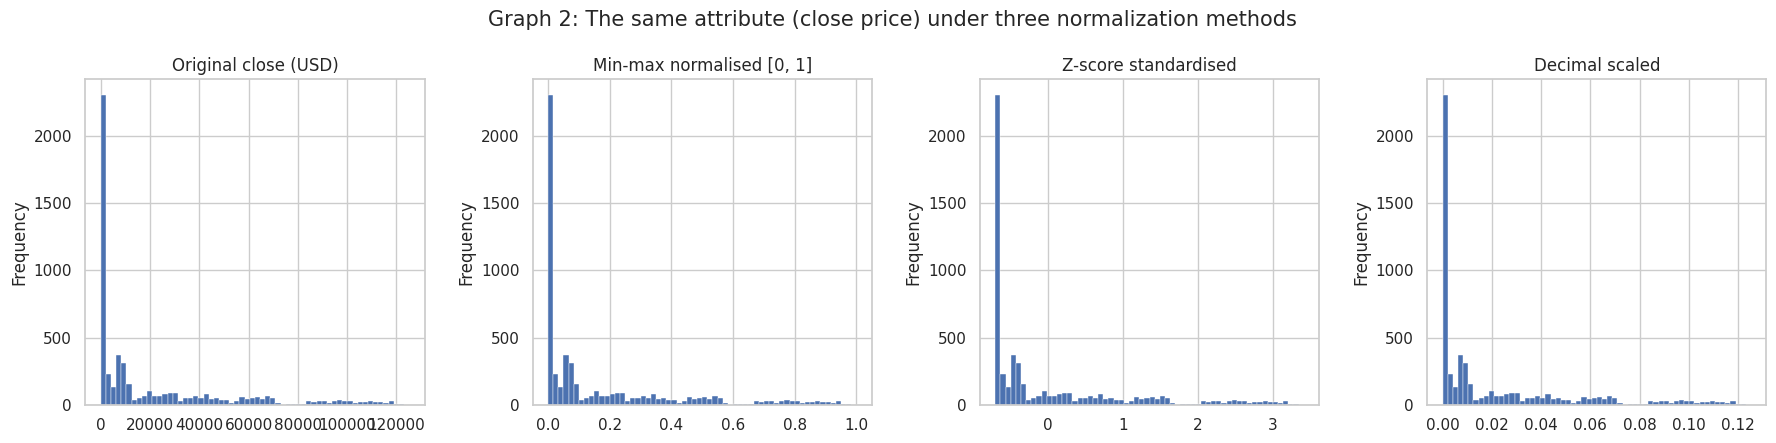

The SHAPE of the distribution is unchanged by all three methods - only the axis changes.
Normalization rescales; it does not transform skewness (a log transform would - see Part C).


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (title, series) in zip(axes, [
        ('Original close (USD)',        df['close']),
        ('Min-max normalised [0, 1]',   norm['close_minmax']),
        ('Z-score standardised',        norm['close_zscore']),
        ('Decimal scaled',              norm['close_decimal'])]):
    ax.hist(series, bins=60, color='#4c72b0', edgecolor='white', linewidth=.3)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Frequency')
fig.suptitle('Graph 2: The same attribute (close price) under three normalization methods', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp4_g2_normalization.png", dpi=150); plt.show()

print("The SHAPE of the distribution is unchanged by all three methods - only the axis changes.")
print("Normalization rescales; it does not transform skewness (a log transform would - see Part C).")

In [13]:
# Why it matters: Euclidean distance between two days, before and after scaling
a, b = df.iloc[1000], df.iloc[4000]
pair = ['close', 'daily_pct_change', 'rsi_14']
raw_d = np.sqrt(sum((a[c] - b[c]) ** 2 for c in pair))
z = norm.iloc[[1000, 4000]]
z_d = np.sqrt(sum((z.iloc[0][f'{c}_zscore'] - z.iloc[1][f'{c}_zscore']) ** 2 for c in pair))
print(f"Two sample days: {a['date'].date()} and {b['date'].date()}")
for c in pair:
    print(f"   {c:18s} {a[c]:12.3f}  vs {b[c]:12.3f}")
print(f"\nEuclidean distance on RAW values        : {raw_d:12.3f}")
print(f"Euclidean distance on Z-SCORED values   : {z_d:12.3f}")
contrib = {c: (a[c]-b[c])**2 / raw_d**2 * 100 for c in pair}
print("\nShare of the RAW distance contributed by each attribute:")
for c, v in contrib.items():
    print(f"   {c:18s} {v:6.2f}%")
print("-> close price alone accounts for essentially the whole distance; without scaling,")
print("   any distance-based model would be a model of the price level and nothing else.")

Two sample days: 2013-10-28 and 2022-01-14
   close                   206.900  vs    43263.500
   daily_pct_change         -0.005  vs        1.530
   rsi_14                   65.969  vs       39.997

Euclidean distance on RAW values        :    43056.608
Euclidean distance on Z-SCORED values   :        2.275

Share of the RAW distance contributed by each attribute:
   close              100.00%
   daily_pct_change     0.00%
   rsi_14               0.00%
-> close price alone accounts for essentially the whole distance; without scaling,
   any distance-based model would be a model of the price level and nothing else.


## 4. Data Discretization

Discretization converts a continuous attribute into a small number of labelled intervals. It is required
for the Apriori algorithm in Experiment 8 (which needs items, not numbers), it makes Naive Bayes in
Experiment 5 easier to interpret, and it reduces the effect of extreme values.

Three methods are implemented:

1. **Equal-width binning** — the range is cut into *k* intervals of equal size. Simple, but skewed data
   piles into one bin.
2. **Equal-frequency (quantile) binning** — each bin holds the same number of records. Robust to skew;
   bin widths become uneven.
3. **Domain-based binning** — cut-points come from the meaning of the attribute (for RSI, the standard
   30 / 70 thresholds).

In [14]:
def equal_width_bins(s, k):
    lo, hi = s.min(), s.max()
    edges = np.linspace(lo, hi, k + 1)
    return pd.cut(s, bins=edges, include_lowest=True), edges

def equal_frequency_bins(s, k):
    edges = np.unique(s.quantile(np.linspace(0, 1, k + 1)).values)
    return pd.cut(s, bins=edges, include_lowest=True, duplicates='drop'), edges

K = 5
ew, ew_edges = equal_width_bins(df['daily_pct_change'], K)
ef, ef_edges = equal_frequency_bins(df['daily_pct_change'], K)

print(f"EQUAL-WIDTH binning of daily_pct_change (k = {K})")
print("  cut-points:", np.round(ew_edges, 3))
print(ew.value_counts().sort_index().to_string())
print(f"\nEQUAL-FREQUENCY binning of daily_pct_change (k = {K})")
print("  cut-points:", np.round(ef_edges, 3))
print(ef.value_counts().sort_index().to_string())
print("\nEqual width puts", f"{ew.value_counts().max() / len(df) * 100:.1f}%",
      "of all days in a single bin; equal frequency keeps every bin at ~20%.")

EQUAL-WIDTH binning of daily_pct_change (k = 5)
  cut-points: [-57.206  21.603 100.412 179.221 258.03  336.839]
daily_pct_change
(-57.207, 21.603]     5511
(21.603, 100.412]       21
(100.412, 179.221]       1
(179.221, 258.03]        0
(258.03, 336.839]        1

EQUAL-FREQUENCY binning of daily_pct_change (k = 5)
  cut-points: [-57.206  -1.849  -0.341   0.588   2.431 336.839]
daily_pct_change
(-57.207, -1.849]    1107
(-1.849, -0.341]     1107
(-0.341, 0.588]      1106
(0.588, 2.431]       1107
(2.431, 336.839]     1107

Equal width puts 99.6% of all days in a single bin; equal frequency keeps every bin at ~20%.


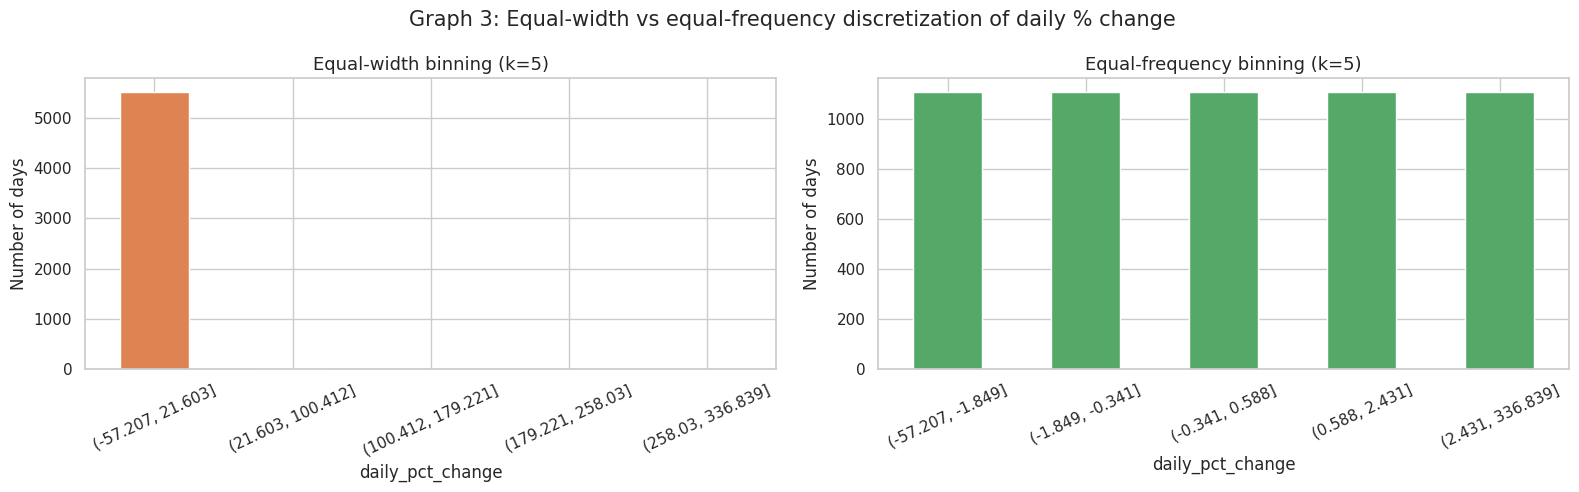

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ew.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#dd8452')
axes[0].set_title(f'Equal-width binning (k={K})', fontsize=13)
axes[0].set_ylabel('Number of days'); axes[0].tick_params(axis='x', rotation=25)
ef.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55a868')
axes[1].set_title(f'Equal-frequency binning (k={K})', fontsize=13)
axes[1].set_ylabel('Number of days'); axes[1].tick_params(axis='x', rotation=25)
fig.suptitle('Graph 3: Equal-width vs equal-frequency discretization of daily % change', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp4_g3_binning.png", dpi=150); plt.show()

In [16]:
# Domain-based discretization - the labels used by Experiments 5, 7 and 8
df['move_class'] = pd.cut(df['daily_pct_change'],
                          bins=[-np.inf, -5, -1, 1, 5, np.inf],
                          labels=['Large Fall', 'Fall', 'Flat', 'Rise', 'Large Rise'])
df['rsi_zone'] = pd.cut(df['rsi_14'], bins=[0, 30, 70, 100],
                        labels=['Oversold', 'Neutral', 'Overbought'])
df['range_band'] = pd.cut(df['daily_range'] / df['open'] * 100,
                          bins=[-np.inf, 3, 8, np.inf], labels=['Low', 'Medium', 'High'])
df['trend'] = np.where(df['close'] > df['ma_200'], 'Above 200-MA', 'Below 200-MA')

for col in ['move_class', 'rsi_zone', 'range_band', 'trend']:
    counts = df[col].value_counts().reindex(
        df[col].cat.categories if hasattr(df[col], 'cat') else sorted(df[col].unique()))
    print(f"\n{col}")
    for k, v in counts.items():
        print(f"   {str(k):14s} {v:5d}  ({v/len(df)*100:5.2f}%)")


move_class
   Large Fall       355  ( 6.41%)
   Fall            1267  (22.89%)
   Flat            2047  (36.99%)
   Rise            1413  (25.53%)
   Large Rise       452  ( 8.17%)

rsi_zone
   Oversold         209  ( 3.78%)
   Neutral         4488  (81.10%)
   Overbought       837  (15.12%)

range_band
   Low             1847  (33.38%)
   Medium          2634  (47.60%)
   High            1053  (19.03%)

trend
   Above 200-MA    3533  (63.84%)
   Below 200-MA    2001  (36.16%)


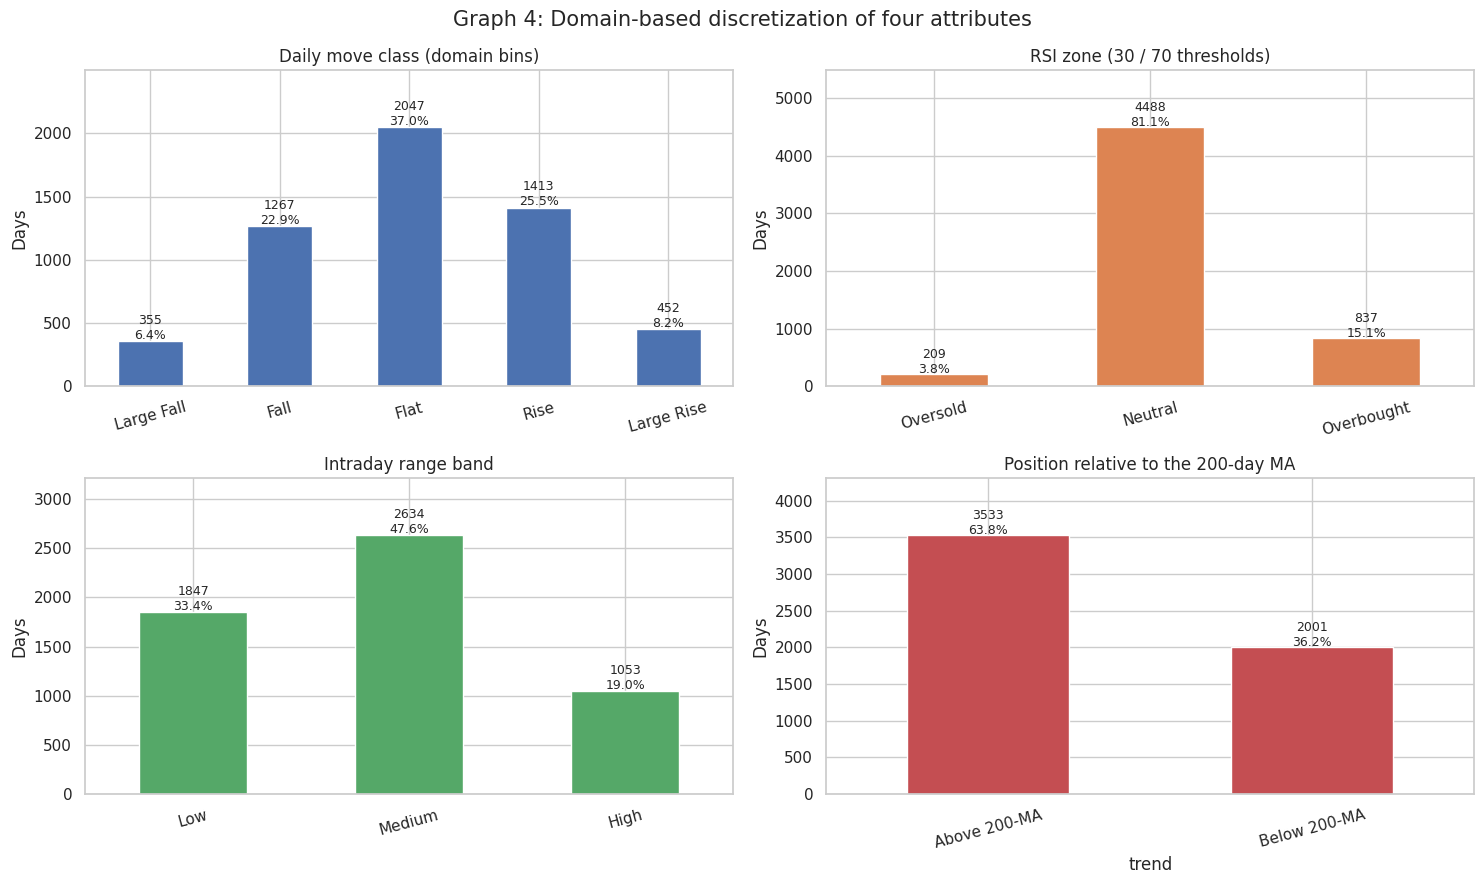

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
specs = [('move_class', '#4c72b0', 'Daily move class (domain bins)'),
         ('rsi_zone', '#dd8452', 'RSI zone (30 / 70 thresholds)'),
         ('range_band', '#55a868', 'Intraday range band'),
         ('trend', '#c44e52', 'Position relative to the 200-day MA')]
for ax, (col, colour, title) in zip(axes.ravel(), specs):
    vc = df[col].value_counts()
    vc = vc.reindex(df[col].cat.categories) if hasattr(df[col], 'cat') else vc.sort_index()
    vc.plot(kind='bar', ax=ax, color=colour)
    for i, v in enumerate(vc):
        ax.text(i, v + 20, f"{v}\n{v/len(df)*100:.1f}%", ha='center', fontsize=9)
    ax.set_title(title, fontsize=12); ax.set_ylabel('Days'); ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, vc.max() * 1.22)
fig.suptitle('Graph 4: Domain-based discretization of four attributes', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp4_g4_domain_bins.png", dpi=150); plt.show()

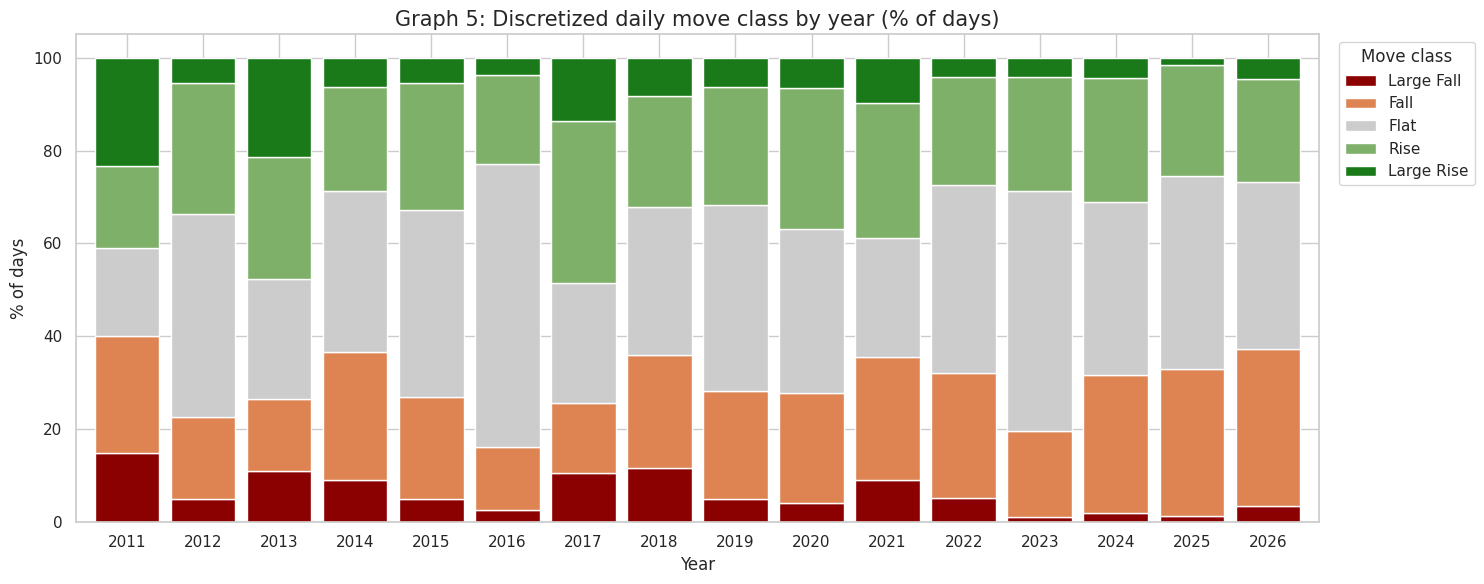

Share of |move| > 5% days per year:
date
2011    38.3
2012    10.4
2013    32.3
2014    15.3
2015    10.4
2016     6.6
2017    24.4
2018    20.0
2019    11.2
2020    10.7
2021    18.9
2022     9.3
2023     5.2
2024     6.3
2025     3.0
2026     8.1


In [18]:
# How the discretized market has changed over time
mix = pd.crosstab(df['date'].dt.year, df['move_class'], normalize='index') * 100
mix.plot(kind='bar', stacked=True, figsize=(15, 6),
         color=['#8b0000', '#dd8452', '#cccccc', '#7fb069', '#1a7a1a'], width=.85)
plt.title('Graph 5: Discretized daily move class by year (% of days)', fontsize=15)
plt.ylabel('% of days'); plt.xlabel('Year'); plt.xticks(rotation=0)
plt.legend(title='Move class', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.savefig(f"{OUT}/exp4_g5_moveclass_by_year.png", dpi=150); plt.show()
print("Share of |move| > 5% days per year:")
big = (mix['Large Fall'] + mix['Large Rise']).round(1)
print(big.to_string())

In [19]:
# Save the preprocessed dataset that Experiments 5, 7 and 8 consume
export_cols = ['date', 'halving_era', 'open', 'high', 'low', 'close', 'daily_change',
               'daily_pct_change', 'daily_range', 'ma_7', 'ma_30', 'ma_200',
               'volatility_30d', 'macd', 'macd_signal', 'rsi_14', 'is_interpolated',
               'move_class', 'rsi_zone', 'range_band', 'trend']
out = df[export_cols].copy()
out['close_minmax']  = norm['close_minmax'].values
out['close_zscore']  = norm['close_zscore'].values
out['pct_zscore']    = norm['daily_pct_change_zscore'].values
out['range_pct']     = (df['daily_range'] / df['open'] * 100).values
out.to_csv('btc_preprocessed_v1.csv', index=False)
print(f"Saved btc_preprocessed_v1.csv  ({len(out):,} rows x {out.shape[1]} columns)")
out.head()

Saved btc_preprocessed_v1.csv  (5,534 rows x 25 columns)


,date,halving_era,open,high,low,close,daily_change,daily_pct_change,daily_range,ma_7,ma_30,ma_200,volatility_30d,macd,macd_signal,rsi_14,is_interpolated,move_class,rsi_zone,range_band,trend,close_minmax,close_zscore,pct_zscore,range_pct
0,2011-02-01,Genesis Era (50 BTC/block),0.520,0.85,0.5200,0.700,0.180,34.615385,0.3300,0.489014,0.384810,0.178366,9.753646,0.061258,0.041056,85.716762,False,Large Rise,Overbought,High,Above 200-MA,1.597797e-07,-0.697841,5.095573,63.461538
1,2011-02-02,Genesis Era (50 BTC/block),0.700,0.76,0.6900,0.716,0.016,2.285714,0.0700,0.531729,0.398843,0.181698,9.711259,0.075778,0.048000,86.263305,False,Rise,Overbought,High,Above 200-MA,2.876035e-07,-0.697840,0.289216,10.000000
2,2011-02-03,Genesis Era (50 BTC/block),0.716,0.75,0.6501,0.690,-0.026,-3.631285,0.0999,0.570129,0.411880,0.184719,9.789639,0.084217,0.055244,80.849378,False,Fall,Overbought,High,Above 200-MA,7.988987e-08,-0.697841,-0.590446,13.952514
3,2011-02-04,Genesis Era (50 BTC/block),0.690,0.88,0.6700,0.811,0.121,17.536232,0.2100,0.622271,0.428947,0.188370,10.108482,0.099521,0.064099,85.431750,False,Large Rise,Overbought,High,Above 200-MA,1.046557e-06,-0.697837,2.556466,30.434783
4,2011-02-05,Genesis Era (50 BTC/block),0.811,0.92,0.8110,0.920,0.109,13.440197,0.1090,0.690986,0.449680,0.192597,10.225404,0.119073,0.075094,88.176380,False,Large Rise,Overbought,High,Above 200-MA,1.917357e-06,-0.697834,1.947520,13.440197


## 5. Summary of the Preprocessing Pipeline

| Stage | Operation | Effect |
|---|---|---|
| Cleaning (Part A) | duplicate date removed | 5,684 → 5,683 rows |
| Cleaning (Part A) | 50 missing calendar days inserted and interpolated | 5,683 → 5,733 rows, 50 flagged |
| Cleaning (Part A) | derived columns and indicators recomputed | consistent with the repaired prices |
| Cleaning (Part A) | 199 burn-in rows dropped | 5,733 → 5,534 rows, zero nulls |
| Descriptive analysis | central tendency, dispersion, shape, per-era breakdown | drives every later choice |
| Null handling | structural vs at-random nulls treated differently | no imputed indicator history |
| Normalization | min-max, z-score, decimal scaling | distance-based models are no longer dominated by price level |
| Discretization | equal-width, equal-frequency and domain bins | categorical attributes for Naive Bayes and Apriori |

**Output:** `btc_preprocessed_v1.csv` — 5,534 rows, cleaned, normalised and discretized.